# Studentのt検定



# t分布

$$
t = \frac{Z}{\sqrt{V/\nu}}
$$

- $Z$ は平均0、分散1の標準正規分布に従う確率変数です。
- $V$ は自由度νのカイ²分布に従う確率変数です。
- $ν$ は自由度で、通常はサンプルサイズから1を引いた値$（n − 1）$になります。
- $Z$ と $V$ は独立と仮定されます。

カイ２乗分布は「標準正規分布」から得られるので$V$の期待値は$v$になり、$V$を$ν$で割ることで平均1の比率になり、正規化できる（実際の自由度の値が関係なくなる）。
これで母集団の真の分散σ²の代わりにサンプル分散が持つばらつきを反映できる。

t統計量は標準正規変数 $Z$ を、$√(V/ν)$ という「ばらつき補正項」で割る形になる。

**自由度$v$の効果**

$\nu$ が小さいと、分母 $\sqrt{V/\nu}$ が大きくなります。これにより $t$ の値が小さくなる可能性があります。実際の分布では、自由度が低い場合、t 分布は正規分布よりも裾が厚くなる傾向があります。

$\nu$ が大きくなると、$\sqrt{V/\nu}$ が小さくなるため、$t$ の値が相対的に大きくなる傾向があります。自由度が無限大に近づくと t 分布は正規分布に近似されます。


（t分布とカイ2乗分布の自由度による変化のアニメーション：プレビュー）

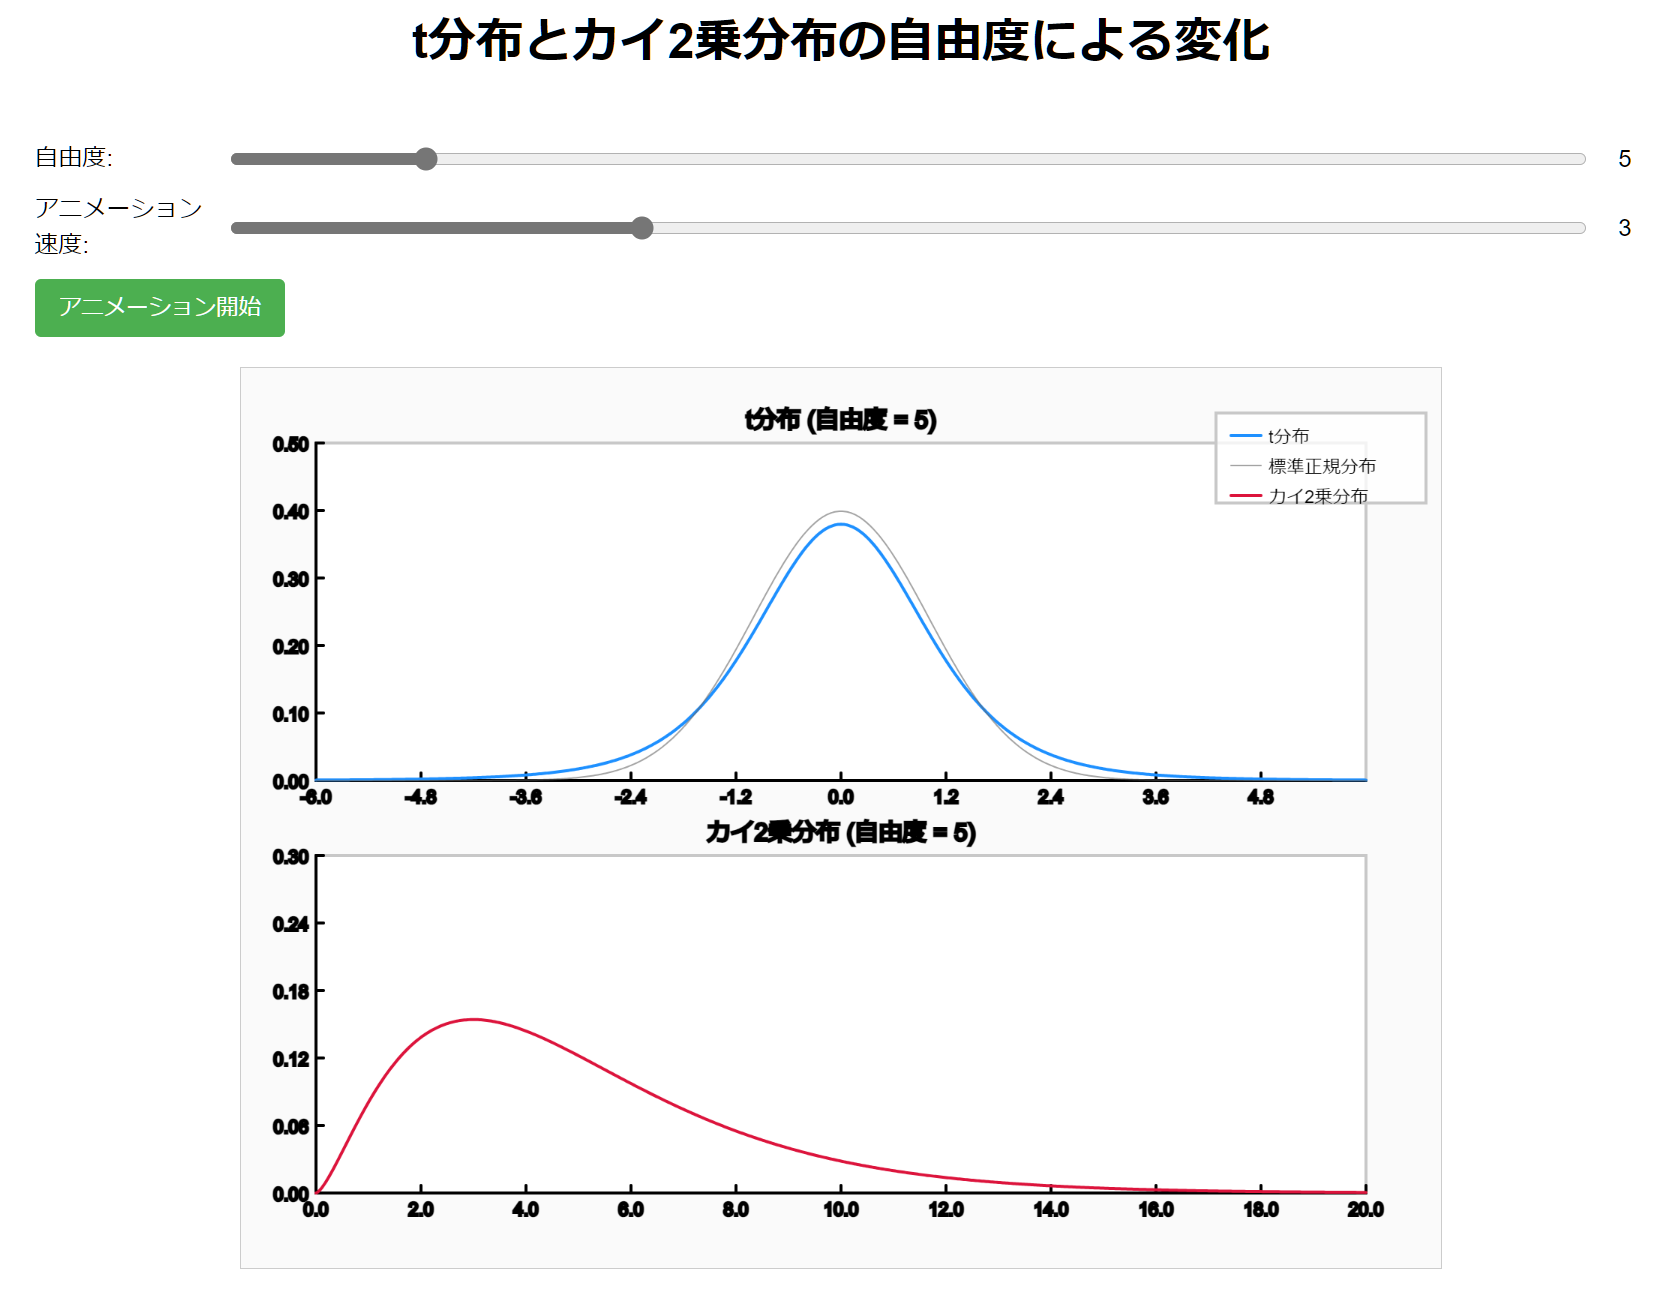

[t分布とカイ2乗分布の自由度による変化のアニメーションのページを開く](https://yoshiwatanabe.github.io/python-test/degree_of_freedom_t_test.html)

## 自由度とt分布

以下のコードで、いくつかの自由度と、対応するt分布を確認できます。

In [2]:
pip install japanize-matplotlib

     ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
     ---------------------------------------- 4.1/4.1 MB 35.4 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120323 sha256=57ae9e22972349e0fe54349252bc7f36e19076627071dac5174eadf11e1e301e
  Stored in directory: c:\users\tsuyo\appdata\local\pip\cache\wheels\da\a1\71\b8faeb93276fed10edffcca20746f1ef6f8d9e071eee8425fc
Successfully built japanize-matplotlib
Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: Building 'japanize-matplotlib' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'japanize-matplotlib'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from scipy.stats import t, norm

x = np.linspace(-5, 5, 400)
dfs = [1, 3, 10, 30]

plt.figure(figsize=(10, 6))
for df in dfs:
    plt.plot(x, t.pdf(x, df), label=f't分布 (df={df})')

plt.plot(x, norm.pdf(x, 0, 1), 'k--', label='標準正規分布')
plt.xlabel('x')
plt.ylabel('確率密度')
plt.title('自由度ごとのt分布と標準正規分布')
plt.legend()
plt.show()


ModuleNotFoundError: No module named 'scipy'

可視化から分かること

自由度が低い青の分布（df=1）では全体的に厚みがあり、両端が大きい。なぜなら少ないサンプルなので極端な値が出る確率が上がるから。
自由度が高い赤の分布（df=130）では標準正規分布に近づく。なぜなら十分なサンプルなので分散の推定の確実性が上がるから。


# t検定

ここでは1標本t検定と独立2標本t検定を学びます。

**1標本t検定**は1つのグループの平均が基準値と異なるかを評価するのに対し、**独立2標本t検定**は2つのグループ間の平均値の差を比較するために使用されます

## 1標本t検定 One-sample t-test

**活用例**

- 新薬の効果検証：薬の投与後の平均血圧が既存の基準値と異なるかどうかを検証。
- 教育プログラムの評価：新しい授業方法後のテスト平均点が標準平均点と異なるか確認。
- 機械の性能検査：製造ラインでの部品寸法平均値が基準値を満たしているかどうかを評価。

**評価式**

$$
t = \frac{\bar{x} - \mu}{s / \sqrt{n}}
$$

- $\bar{x}$：サンプルの平均値
- $\mu$：検定対象となる母平均（または既知の基準値）
- $s$：サンプル標準偏差（データのばらつきを示す）
- $n$：サンプルサイズ（自由度は $n - 1$）

- **目的**：1つの集団から抽出したサンプルの平均が、既知または仮定した母平均と統計的に有意に異なるかどうかを検定します。  
- **標準誤差**：分母の $s/√n$ は、サンプル平均のばらつきを示す標準誤差となり、サンプルサイズが大きいほど小さくなります。  
- **t分布との関係**：理論的には、母分散が既知ならば $(x̄ − μ)/(σ/√n)$ は標準正規分布に従いますが、実際には$σ$が不明なため、サンプル標準偏差 $s$ を代用します。  
  このとき、t統計量は  
  $t = Z / √(V/ν)$  
  （Z：標準正規変数、$V$：自由度$ν$のカイ²分布変数）  
の形で導かれ、サンプル分散の不確かさ$（V/ν）$を反映して、自由度 $n − 1$ のt分布に従います。

## 独立2標本t検定 Independnt two-sample t-test

**活用例**

- 治療法比較：2つの異なる治療法による患者の改善率の平均値を比較。
- スポーツトレーニング効果：異なるトレーニング方法を受けたグループの平均スコアを比較。
- マーケティングキャンペーン分析：異なる広告手法による売上の平均値の違いを検討。

**式（等分散を仮定する場合）**


$$
t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{s_p^2 \left(\frac{1}{n_1} + \frac{1}{n_2}\right)}}
$$

$$
s_p^2 = \frac{(n_1 - 1)s_1^2 + (n_2 - 1)s_2^2}{n_1 + n_2 - 2}
$$

- $\bar{x}_1, \bar{x}_2$：それぞれのグループのサンプル平均
- $s_1, s_2$：各グループの標準偏差
- $n_1, n_2$：各グループのサンプルサイズ
- $s_p^2$：プールされた分散（両グループのデータのばらつきを合わせたもの）

- **目的**：2つの独立した集団の平均値が等しいかどうかを検定します。  
- **プール分散**：両群の分散が等しいと仮定し、各群のサンプルサイズに応じた重み付き平均で分散を推定します。  
- **標準誤差**：差の標準誤差は $√[ s_p² (1/n₁ + 1/n₂) ]$ により求められ、差が標準誤差に比して大きければ t値も大きくなります。  
- **t分布との関係**：分子は2つの標本平均の差で、もし母分散が既知ならば標準正規分布に従いますが、実際は推定値$（s₁, s₂）$を用いるため、ばらつきの補正として各群の分散の推定がカイ²分布の性質を持ちます。結果、t統計量は自由度 $n₁+n₂−2$ のt分布に従います。

## t分布との共通の背景

- **t統計量の一般形**  
  $t = Z / √(V/ν)$  
  - $Z$：母分散が既知の場合に用いる標準正規分布の変数  
  - $V$：サンプル分散（やその拡大版）が従うカイ²分布変数  
  - $ν$：自由度（通常はサンプルサイズから1または2群の場合は n₁+n₂−2）

- **不確実性の反映**  
  母分散が未知の場合、サンプルから推定する標準偏差にはばらつきがあり、そのばらつきがカイ²分布の性質で表されます。  
  そのため、標本平均の差を標準化する際に、推定された標準偏差の不確実性を $√(V/ν)$ という形で補正し、結果としてt統計量はt分布に従います。  
- **自由度の影響**  
  自由度が少ない場合、$V/ν$ のばらつきが大きく、t分布は裾が厚い（極端な値が出やすい）形状になります。自由度が大きくなると、$V/ν$ が1に近づき、t分布は標準正規分布に収束します。

